In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from tqdm import tqdm

In [2]:
# functions

def half_mass_radius(radii, masses):
    idr = np.argsort(radii)
    r_sorted = radii[idr]
    m_sorted = masses[idr]    
    m_cum = np.cumsum(m_sorted)
    m_half = 0.5 * np.sum(masses)    
    i = np.searchsorted(m_cum, m_half)
    return r_sorted[i]

def radius(pos, centre):
    return np.sqrt((pos[:,0]-centre[0])**2 + (pos[:,1]-centre[1])**2 + (pos[:,2]-centre[2])**2)

def velocity(vel):
    return np.sqrt((vel[:,0])**2 + (vel[:,1])**2 + (vel[:,2])**2)

In [3]:
s1_pos = []
s1_vel = []
s1_mbp = []
s1_mass = []
r1s = []
v1s = []
HMRs = []
IDs = []

g1_pos = []
g1_vel = []
g1_mass = []
r1g = []
v1g = []
HMRg = []
IDg = []

s2_mbp = []

In [4]:
secondary = True

for n in tqdm(range(100)):
    g1 = h5py.File('GettingStarted/particles_snap_0'+f"{n:02d}"+'_galID341536_Primary.hdf5', 'r')
    #########  STARS #########
    s1_mbp.append(g1['Star']['MostBoundParticle'][:])
    s1_mass.append(g1['Star']['Mass'][:])
    # position & radii
    s1_pos.append(g1['Star']['Position'][:])
    r1s.append(radius(s1_pos[-1], s1_mbp[-1]))
    # velocities
    s1_vel.append(g1['Star']['Velocity'][:])
    v1s.append(velocity(s1_vel[-1]))
    # half-mass radius
    HMRs.append( half_mass_radius(r1s[-1], s1_mass[-1][:]) )
    # particle ID
    IDs.append(g1['Star']['ParticleID'])
    
    #########  GAS #########
    g1_mass.append(g1['Gas']['Mass'][:])
    # position & radii
    g1_pos.append(g1['Gas']['Position'][:])
    r1g.append(radius(g1_pos[-1], s1_mbp[-1]))
    # velocities
    g1_vel.append(g1['Gas']['Velocity'][:])
    v1g.append(velocity(g1_vel[-1]))
    # half-mass radius
    HMRg.append( half_mass_radius(r1g[-1], g1_mass[-1][:]) )
    IDg.append(g1['Gas']['ParticleID'])

 
    if (n>2)&(n<50)&(secondary==True):
        g2 = h5py.File('GettingStarted/particles_snap_0'+f"{n:02d}"+'_galID341536_Secondary.hdf5', 'r')
        s2_mbp.append(g2['Star']['MostBoundParticle'][:])

g1.keys()

100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [02:30<00:00,  1.50s/it]


<KeysViewHDF5 ['BlackHole', 'Gas', 'Header', 'Star']>

In [5]:
for name in g1['Header'].attrs.keys():
    print(name, '\t', g1['Header'].attrs[name])

Accretion_Units 	 Msun/yr
Masses_Units 	 Msun
Pos_Units 	 kpc (proper-physical)
Potential 	 (km/s)^2
Vel_Units 	 km/s


In [6]:
for name in g1['BlackHole'].keys():
    print(name, '\t', g1['BlackHole'][name][:])

BH_Density 	 [104969.195]
BH_Mass 	 [1.399248e+08]
BH_Mdot 	 [3.9989867e-05]
BH_MdotBondi 	 [3.9989864e-05]
BH_MdotEddington 	 [1.5518297]
Mass 	 [1.399248e+08]
ParticleIDs 	 [114734816996]
Position 	 [[12039.58064209 37506.48265626 42152.11920013]]
Potential 	 [-275354.40625]
Velocity 	 [[ -21.4461956     4.28502131 -289.47714233]]


In [7]:
print(g1['Gas'].keys())
print(g1['Star'].keys())

<KeysViewHDF5 ['Mass', 'ParticleID', 'Position', 'StarFormationRate', 'Velocity']>
<KeysViewHDF5 ['Mass', 'MostBoundParticle', 'MostBoundParticleVel', 'ParticleID', 'Position', 'Potential', 'StarFormationTime', 'Velocity']>


### Number of particles

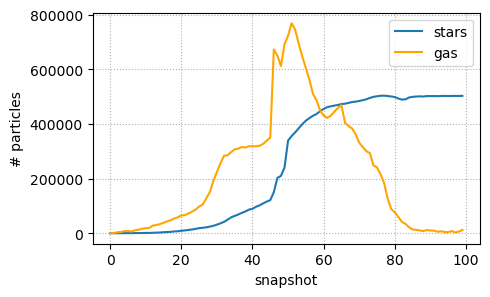

In [11]:
ns = []
ng = []
for i in range(100):
    ns.append(len(s1_pos[i]))
    ng.append(len(g1_pos[i]))

plt.figure(figsize=(5,3))
plt.plot(ns, label='stars')
plt.plot(ng, c='orange', label='gas')
plt.xlabel('snapshot')
plt.ylabel('# particles')
plt.grid(ls='dotted')
plt.legend()
plt.show()

### Half-mass radius

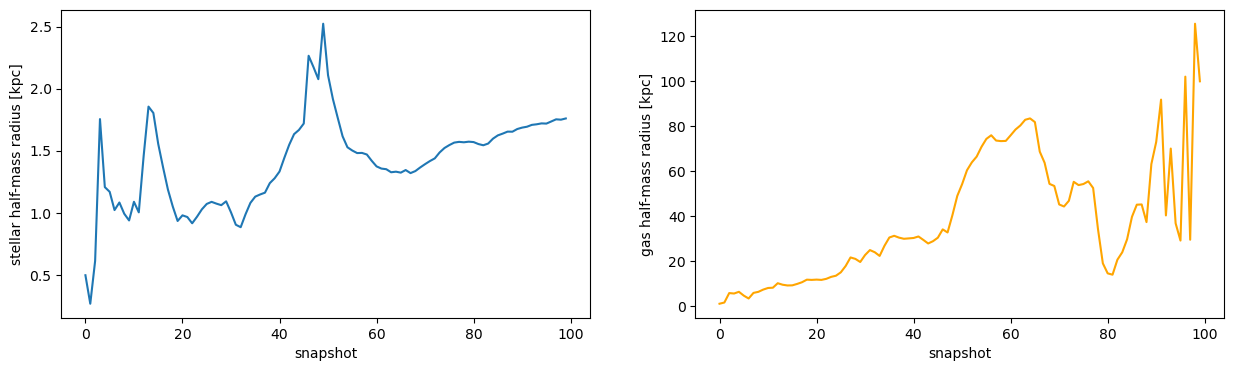

In [8]:
fig = plt.figure(figsize=(15,4))

ax = fig.add_subplot(121)
ax.plot(HMRs)
plt.xlabel('snapshot')
plt.ylabel('stellar half-mass radius [kpc]')

ax = fig.add_subplot(122)
ax.plot(HMRg, c='orange')
plt.xlabel('snapshot')
plt.ylabel('gas half-mass radius [kpc]')
plt.show()

## 2D plot

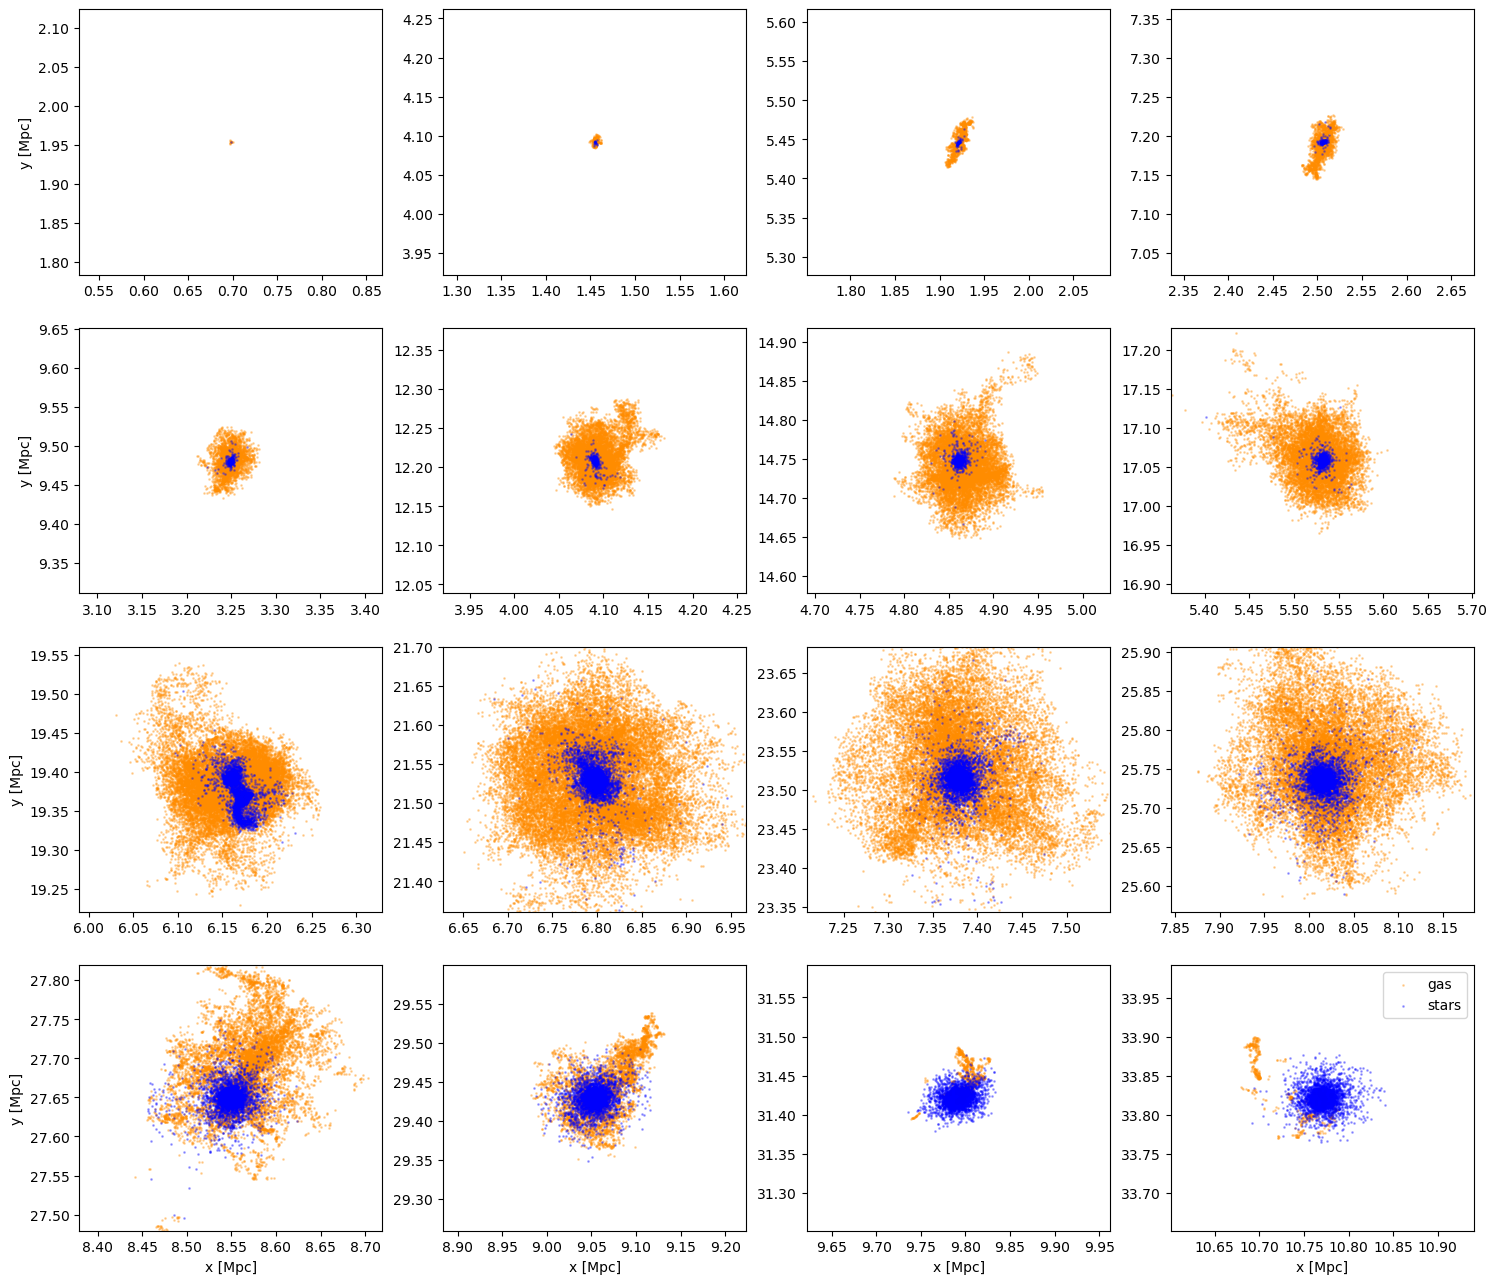

In [85]:
n = 16  # number of frames
rows = int(n/4)+1
ds = 20 # downsampling

fig = plt.figure(figsize=(18,n/4*5))

for i in range(n):
    ax = fig.add_subplot(rows,4,i+1)
    j = int(i*int(100/n))
    plt.scatter(np.array(g1_pos[j])[::ds,0] / 1000, np.array(g1_pos[j])[::ds,1] / 1000, s=1, color='darkorange', alpha=0.3, label='gas')
    plt.scatter(np.array(s1_pos[j])[::ds,0] / 1000, np.array(s1_pos[j])[::ds,1] / 1000, s=1, color='b', alpha=0.3, label='stars')
    
    dd = 0.17
    plt.xlim(s1_mbp[j][0]/1000-dd, s1_mbp[j][0]/1000+dd)
    plt.ylim(s1_mbp[j][1]/1000-dd, s1_mbp[j][1]/1000+dd)
    if int(i/4)>=int(n/4)-1:
        plt.xlabel('x [Mpc]')
    if i%4==0:
        plt.ylabel('y [Mpc]')
    
plt.legend()
plt.show()

### Mean velocity

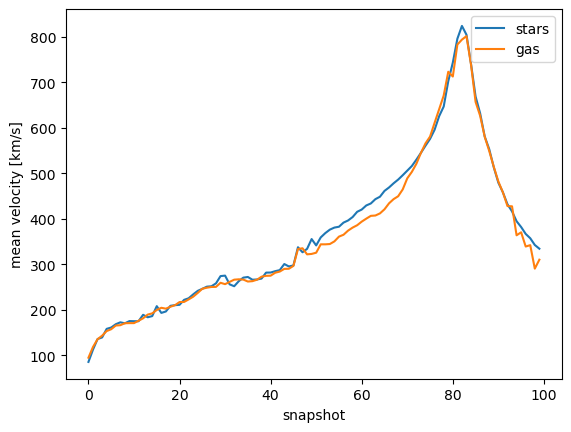

In [9]:
mean_vel_stars = []
mean_vel_gas = []

for i in range(100):
    mean_vel_stars.append(np.mean(v1s[i]))
    mean_vel_gas.append(np.mean(v1g[i]))

plt.plot(mean_vel_stars, label='stars')
plt.plot(mean_vel_gas, label='gas')

plt.xlabel('snapshot')
plt.ylabel('mean velocity [km/s]')
plt.legend()
plt.show()

### M(r)

100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:14<00:00,  6.96it/s]


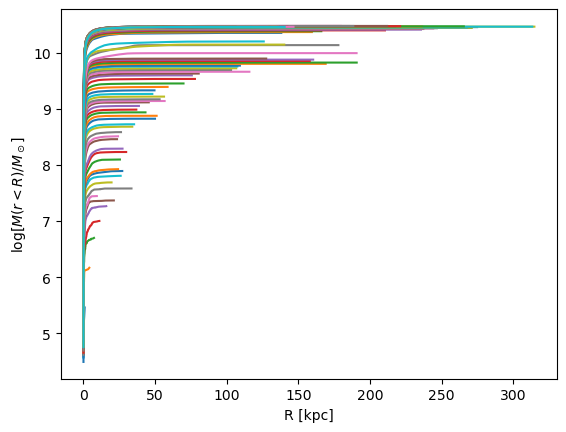

In [21]:
# mass-radius relation
for k in tqdm(range(100)):
    idr = np.argsort(r1s[k])
    r_sorted = r1s[k][idr]
    m_sorted = s1_mass[k][idr]    
    m_cum = np.cumsum(m_sorted)
    plt.plot(r1s[k][idr], np.log10(m_cum))

plt.xlabel('R [kpc]')
plt.ylabel('log[$M(r<R)/M_\odot$]')
plt.show()